# Лабораторная работа 2


## Шаг 1: Выбор датасета

В этой ячейке мы подключаем все необходимые библиотеки. Pandas и NumPy работают с данными, sklearn предоставляет инструменты для предобработки, matplotlib и seaborn нужны для визуализации результатов. Датасет Titanic загружается через seaborn. Это встроенный датасет, поэтому не требует скачивания.

In [ ]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Библиотеки для предобработки данных
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Настройка отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Отключение предупреждений
import warnings
warnings.filterwarnings('ignore')

print("Библиотеки успешно импортированы")


df = sns.load_dataset('titanic')
print("Датасет загружен!")
print(f"Размер: {df.shape[0]} строк, {df.shape[1]} столбцов")

Библиотеки успешно импортированы
Датасет загружен!
Размер: 891 строк, 15 столбцов


## Шаг 2: Первичный анализ данных

 Здесь мы выполняем первичный осмотр данных. Метод head() показывает пример записей, info() отображает типы столбцов и количество не-пустых значений, а расчёт процентов пропусков помогает определить стратегию обработки. Визуализация помогает наглядно оценить масштаб проблемы с пропусками. Признак deck имеет 77% пропусков — его целесообразно удалить. age и embarked имеют меньше пропусков и подлежат заполнению.

Первые 5 строк датасета:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.000,1,0,7.250,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.000,1,0,71.283,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.000,0,0,7.925,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.000,1,0,53.100,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.000,0,0,8.050,S,Third,man,True,NaN,Southampton,no,True



Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None

Пропущенные значения:


,Пропуски,Процент
age,177,19.870
embarked,2,0.220
deck,688,77.220
embark_town,2,0.220


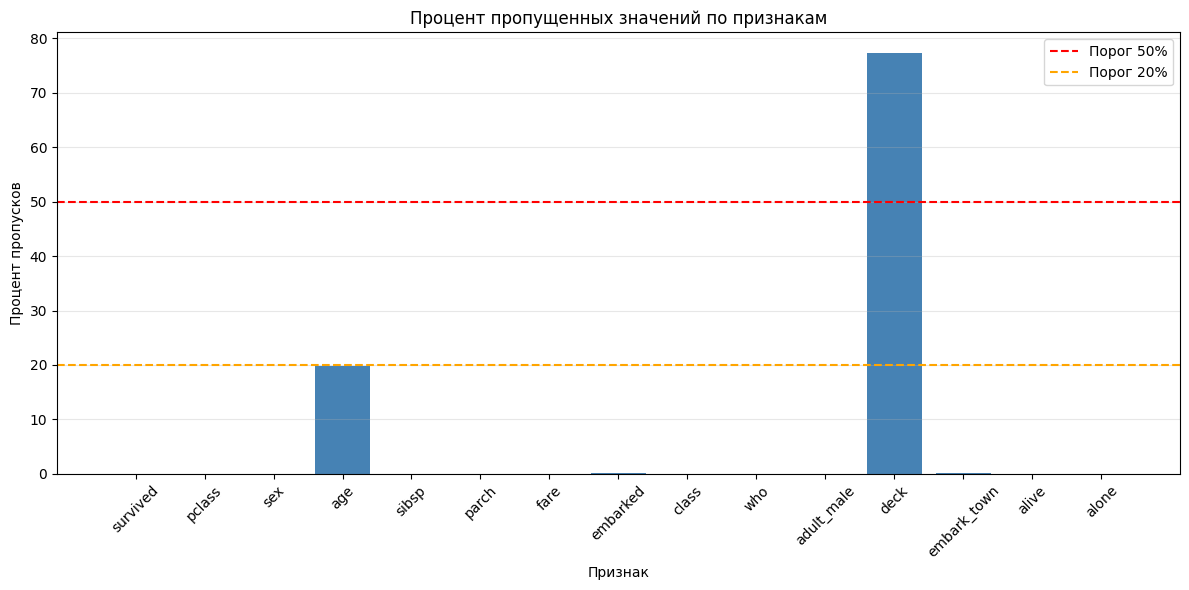


Выводы по пропускам:
- deck: 77.22% - рекомендуется удалить признак
- age: 19.87% - можно заполнить медианой/средним
- embarked: 0.22% - можно заполнить модой


In [ ]:
# Просмотр первых строк датасета
print("Первые 5 строк датасета:")
display(df.head())

# Информация о типах данных и пропусках
print("\nИнформация о датасете:")
print(df.info())

# Статистика пропущенных значений
print("\nПропущенные значения:")
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Пропуски': missing, 'Процент': missing_percent})
display(missing_df[missing_df['Пропуски'] > 0])

# Визуализация пропущенных значений
plt.figure(figsize=(12, 6))
missing = df.isnull().sum()
missing_percent = (missing / len(df) * 100).round(2)

plt.bar(missing.index, missing_percent, color='steelblue')
plt.axhline(y=50, color='r', linestyle='--', label='Порог 50%')
plt.axhline(y=20, color='orange', linestyle='--', label='Порог 20%')
plt.title('Процент пропущенных значений по признакам')
plt.xlabel('Признак')
plt.ylabel('Процент пропусков')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nВыводы по пропускам:")
print(f"- deck: {missing_percent['deck']}% - рекомендуется удалить признак")
print(f"- age: {missing_percent['age']}% - можно заполнить медианой/средним")
print(f"- embarked: {missing_percent['embarked']}% - можно заполнить модой")

## Шаг 3: Обработка пропусков в данных

Мы применяем три стратегии обработки пропусков: (1) удаление признаков с критическим количеством пропусков, (2) заполнение числовых признаков медианой, (3) заполнение категориальных признаков модой. Медиана предпочтительнее среднего для возраста из-за возможных выбросов. SimpleImputer — это автоматизированный способ обработки пропусков из sklearn. Он удобен при построении пайплайнов, так как может быть включён в конвейер предобработки вместе с другими преобразованиями.

In [ ]:
# Создание копии датасета для работы
df_processed = df.copy()

# Стратегия 1: Удаление признаков с большим количеством пропусков (>50%)
print("Удаление признака 'deck' (77% пропусков):")
df_processed = df_processed.drop(columns=['deck'])
print(f"Осталось столбцов: {df_processed.shape[1]}")

# Стратегия 2: Заполнение числовых признаков (age)
print("\nЗаполнение пропусков в 'age':")
print(f"До заполнения: {df_processed['age'].isnull().sum()} пропусков")

# Заполнение медианой (более устойчиво к выбросам)
median_age = df_processed['age'].median()
df_processed['age'] = df_processed['age'].fillna(median_age)

print(f"После заполнения медианой ({median_age:.2f}): {df_processed['age'].isnull().sum()} пропусков")

# Стратегия 3: Заполнение категориальных признаков (embarked)
print("\nЗаполнение пропусков в 'embarked':")
print(f"До заполнения: {df_processed['embarked'].isnull().sum()} пропусков")

# Заполнение модой (наиболее частое значение)
mode_embarked = df_processed['embarked'].mode()[0]
df_processed['embarked'] = df_processed['embarked'].fillna(mode_embarked)

print(f"После заполнения модой ({mode_embarked}): {df_processed['embarked'].isnull().sum()} пропусков")

# Проверка всех пропусков
print("\nОставшиеся пропуски:")
print(df_processed.isnull().sum())



# Альтернативный способ: использование SimpleImputer из sklearn
from sklearn.impute import SimpleImputer

df_imputer = df.copy()
df_imputer = df_imputer.drop(columns=['deck'])

# Числовые признаки
num_cols = ['age', 'fare']
num_imputer = SimpleImputer(strategy='median')
df_imputer[num_cols] = num_imputer.fit_transform(df_imputer[num_cols])

# Категориальные признаки
cat_cols = ['embarked', 'embark_town']
cat_imputer = SimpleImputer(strategy='most_frequent')
df_imputer[cat_cols] = cat_imputer.fit_transform(df_imputer[cat_cols])

print("\nПропуски после SimpleImputer:")
print(df_imputer.isnull().sum())

Удаление признака 'deck' (77% пропусков):
Осталось столбцов: 14

Заполнение пропусков в 'age':
До заполнения: 177 пропусков
После заполнения медианой (28.00): 0 пропусков

Заполнение пропусков в 'embarked':
До заполнения: 2 пропусков
После заполнения модой (S): 0 пропусков

Оставшиеся пропуски:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

Пропуски после SimpleImputer:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


## Шаг 4: Кодирование категориальных признаков

Перед кодированием необходимо идентифицировать все категориальные признаки и понять их уникальные значения. Это поможет выбрать подходящий метод кодирования. Label Encoding преобразует категории в числа от 0 до n-1. Подходит для бинарных признаков (пол) или порядковых переменных. Недостаток: может создать ложное представление о порядке между категориями. One-Hot Encoding создаёт отдельный бинарный столбец для каждой категории. Подходит для номинальных признаков без порядка. Избегает проблемы ложного порядка, но увеличивает размерность данных. ColumnTransformer позволяет применять разные преобразования к разным столбцам в одном конвейере. Параметр drop='first' удаляет первый столбец для избежания мультиколлинеарности. Это предпочтительный способ для production-кода.

In [ ]:
# Выделение категориальных признаков
categorical_cols = ['sex', 'embarked', 'class', 'who', 'adult_male', 'alone', 'embark_town']
print("Категориальные признаки:", categorical_cols)

# Проверка уникальных значений
print("\nУникальные значения:")
for col in categorical_cols:
    print(f"{col}: {df_processed[col].unique()}")

Категориальные признаки: ['sex', 'embarked', 'class', 'who', 'adult_male', 'alone', 'embark_town']

Уникальные значения:
sex: ['male' 'female']
embarked: ['S' 'C' 'Q']
class: ['Third', 'First', 'Second']
Categories (3, object): ['First', 'Second', 'Third']
who: ['man' 'woman' 'child']
adult_male: [ True False]
alone: [False  True]
embark_town: ['Southampton' 'Cherbourg' 'Queenstown' nan]


In [ ]:
# Метод 1: Label Encoding (для порядковых признаков)
from sklearn.preprocessing import LabelEncoder

df_label = df_processed.copy()

# Создаём копирование для кодирования
le_sex = LabelEncoder()
df_label['sex_encoded'] = le_sex.fit_transform(df_label['sex'])

print("Label Encoding для 'sex':")
print(f"Оригинал: {df_label['sex'].unique()}")
print(f"Кодировка: {df_label['sex_encoded'].unique()}")
print(f"Соответствие: {dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_)))}")

display(df_label[['sex', 'sex_encoded']].head(10))

Label Encoding для 'sex':
Оригинал: ['male' 'female']
Кодировка: [1 0]
Соответствие: {'female': np.int64(0), 'male': np.int64(1)}


,sex,sex_encoded
0,male,1
1,female,0
2,female,0
3,female,0
4,male,1
5,male,1
6,male,1
7,male,1
8,female,0
9,female,0


In [ ]:
# Метод 2: One-Hot Encoding (для номинальных признаков)
df_onehot = df_processed.copy()

# One-Hot Encoding для 'embarked'
df_onehot = pd.get_dummies(df_onehot, columns=['embarked'], prefix='embarked')

print("One-Hot Encoding для 'embarked':")
print(f"Оригинальные столбцы: {['embarked']}")
print(f"Новые столбцы: {[col for col in df_onehot.columns if 'embarked' in col]}")

display(df_onehot[['embarked_C', 'embarked_Q', 'embarked_S']].head(10))

One-Hot Encoding для 'embarked':
Оригинальные столбцы: ['embarked']
Новые столбцы: ['embarked_C', 'embarked_Q', 'embarked_S']


,embarked_C,embarked_Q,embarked_S
0,False,False,True
1,True,False,False
2,False,False,True
3,False,False,True
4,False,False,True
5,False,True,False
6,False,False,True
7,False,False,True
8,False,False,True
9,True,False,False


In [ ]:
# Метод 3: ColumnTransformer для комплексного кодирования
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

df_ct = df_processed.copy()

# Разделение признаков
target = df_ct['survived']
features = df_ct.drop(columns=['survived', 'alive', 'who', 'class', 'adult_male', 'embark_town'])

# Категориальные признаки для One-Hot
cat_features = ['sex', 'embarked']

# One-Hot Encoding через ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
    ],
    remainder='passthrough'
)

# Преобразование
features_encoded = preprocessor.fit_transform(features)

# Получение имён столбцов
cat_encoded_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features)
all_feature_names = list(cat_encoded_names) + [col for col in features.columns if col not in cat_features]

df_final = pd.DataFrame(features_encoded, columns=all_feature_names)
df_final['survived'] = target.values

print("Итоговые признаки после кодирования:")
print(df_final.columns.tolist())
print(f"\nРазмер: {df_final.shape}")
display(df_final.head())

Итоговые признаки после кодирования:
['sex_male', 'embarked_Q', 'embarked_S', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'alone', 'survived']

Размер: (891, 10)


,sex_male,embarked_Q,embarked_S,pclass,age,sibsp,parch,fare,alone,survived
0,1.000,0.000,1.000,3,22.000,1,0,7.250,False,0
1,0.000,0.000,0.000,1,38.000,1,0,71.283,False,1
2,0.000,0.000,1.000,3,26.000,0,0,7.925,True,1
3,0.000,0.000,1.000,1,35.000,1,0,53.100,False,1
4,1.000,0.000,1.000,3,35.000,0,0,8.050,True,0


## Раздел 5: Масштабирование данных

Масштабирование применяется только к числовым признакам. Категориальные признаки после One-Hot Encoding уже находятся в диапазоне 0-1 и не требуют масштабирования. StandardScaler преобразует данные так, чтобы среднее было 0, а стандартное отклонение — 1. Подходит для алгоритмов, предполагающих нормальное распределение (линейная регрессия, логистическая регрессия, SVM). MinMaxScaler масштабирует данные в диапазон [0, 1]. Подходит для нейронных сетей и алгоритмов, чувствительных к абсолютным значениям (KNN, K-Means). Не подходит при наличии выбросов. Boxplot наглядно показывает, как разные методы масштабирования влияют на распределение данных. StandardScaler сохраняет форму распределения, MinMaxScaler сжимает в фиксированный диапазон.

In [ ]:
# Выделение числовых признаков для масштабирования
numeric_cols = ['age', 'sibsp', 'parch', 'fare', 'pclass']

print("Числовые признаки для масштабирования:", numeric_cols)
print("\nСтатистика до масштабирования:")
display(df_final[numeric_cols].describe())

Числовые признаки для масштабирования: ['age', 'sibsp', 'parch', 'fare', 'pclass']

Статистика до масштабирования:


,age,sibsp,parch,fare,pclass
count,891.000,891,891,891.000,891
unique,88.000,7,7,248.000,3
top,28.000,0,0,8.050,3
freq,202.000,608,678,43.000,491


StandardScaler:
Среднее после масштабирования: age       0.000
sibsp     0.000
parch     0.000
fare      0.000
pclass   -0.000
dtype: float64
Стандартное отклонение: age      1.001
sibsp    1.001
parch    1.001
fare     1.001
pclass   1.001
dtype: float64


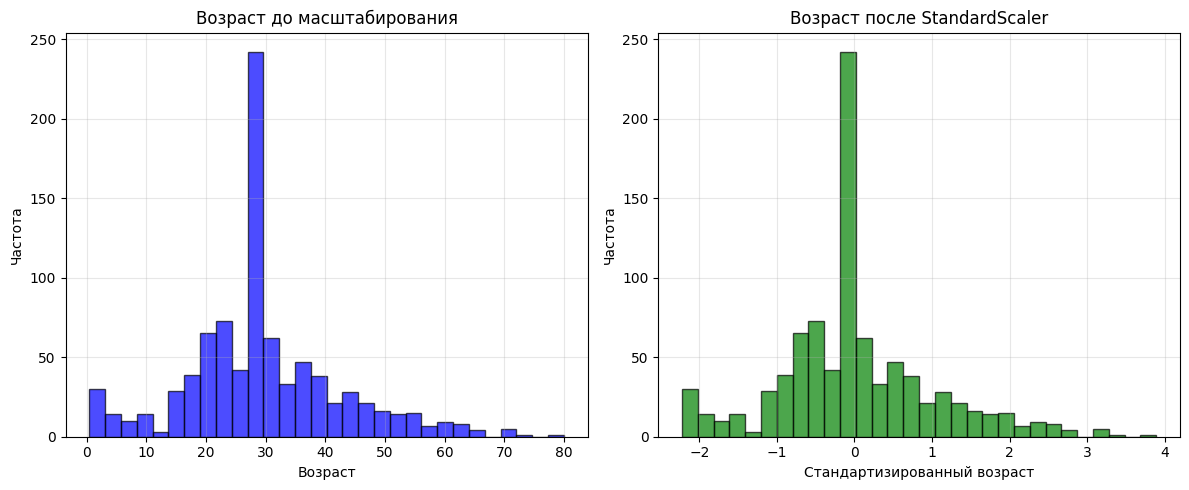

In [ ]:
# Метод 1: StandardScaler (стандартизация)
from sklearn.preprocessing import StandardScaler

df_standard = df_final.copy()

scaler_standard = StandardScaler()
df_standard[numeric_cols] = scaler_standard.fit_transform(df_standard[numeric_cols])

print("StandardScaler:")
print(f"Среднее после масштабирования: {df_standard[numeric_cols].mean().round(5)}")
print(f"Стандартное отклонение: {df_standard[numeric_cols].std().round(5)}")

# Визуализация
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_final['age'], bins=30, color='blue', alpha=0.7, edgecolor='black')
plt.title('Возраст до масштабирования')
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(df_standard['age'], bins=30, color='green', alpha=0.7, edgecolor='black')
plt.title('Возраст после StandardScaler')
plt.xlabel('Стандартизированный возраст')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Метод 2: MinMaxScaler (нормализация)
from sklearn.preprocessing import MinMaxScaler

df_minmax = df_final.copy()

scaler_minmax = MinMaxScaler(feature_range=(0, 1))
df_minmax[numeric_cols] = scaler_minmax.fit_transform(df_minmax[numeric_cols])

print("MinMaxScaler:")
print(f"Минимум после масштабирования: {df_minmax[numeric_cols].min().round(5)}")
print(f"Максимум после масштабирования: {df_minmax[numeric_cols].max().round(5)}")

# Сравнение методов
print("\nСравнение методов масштабирования для 'fare':")
print(f"Оригинал: min={df_final['fare'].min():.2f}, max={df_final['fare'].max():.2f}")
print(f"StandardScaler: min={df_standard['fare'].min():.2f}, max={df_standard['fare'].max():.2f}")
print(f"MinMaxScaler: min={df_minmax['fare'].min():.2f}, max={df_minmax['fare'].max():.2f}")

MinMaxScaler:
Минимум после масштабирования: age      0.000
sibsp    0.000
parch    0.000
fare     0.000
pclass   0.000
dtype: float64
Максимум после масштабирования: age      1.000
sibsp    1.000
parch    1.000
fare     1.000
pclass   1.000
dtype: float64

Сравнение методов масштабирования для 'fare':
Оригинал: min=0.00, max=512.33
StandardScaler: min=-0.65, max=9.67
MinMaxScaler: min=0.00, max=1.00


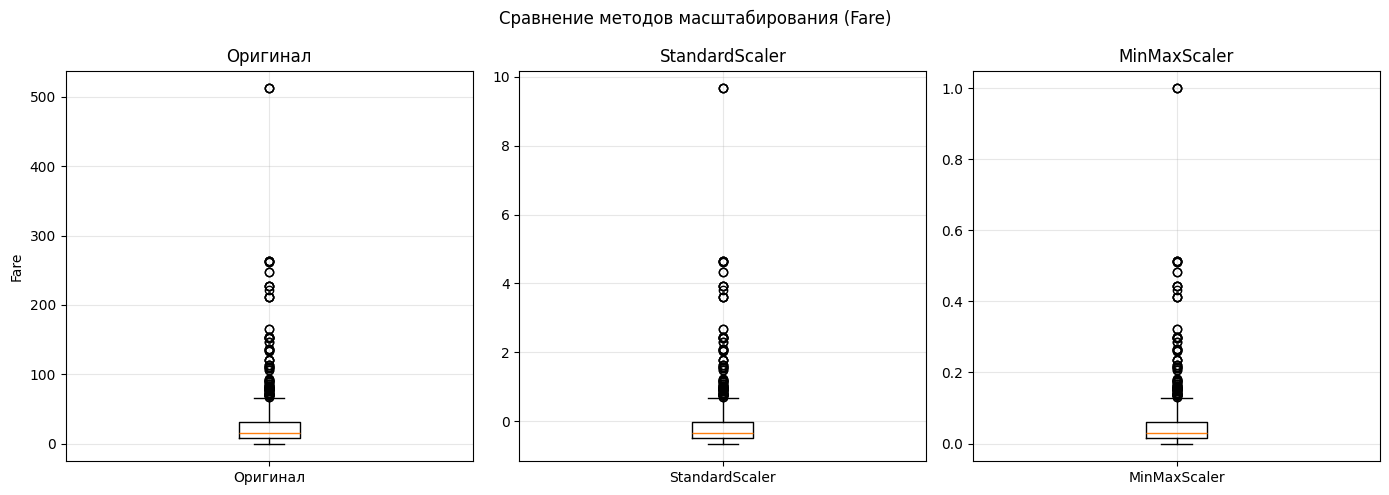

In [ ]:
# Визуализация сравнения методов масштабирования
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.boxplot(df_final['fare'], labels=['Оригинал'])
plt.title('Оригинал')
plt.ylabel('Fare')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.boxplot(df_standard['fare'], labels=['StandardScaler'])
plt.title('StandardScaler')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.boxplot(df_minmax['fare'], labels=['MinMaxScaler'])
plt.title('MinMaxScaler')
plt.grid(True, alpha=0.3)

plt.suptitle('Сравнение методов масштабирования (Fare)')
plt.tight_layout()
plt.show()

## Раздел 6: Полный пайплайн предобработки

Полный пайплайн объединяет все этапы предобработки в один конвейер. Это обеспечивает воспроизводимость и упрощает применение одинаковых преобразований к новым данным (например, к тестовой выборке).
Сохранение результатов позволяет использовать обработанные данные в дальнейшем и прикладывать их к отчёту. Сохранение преобразователя полезно для применения тех же преобразований к новым данным.

In [ ]:
# Создание полного пайплайна предобработки
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Загрузка исходных данных
df_pipeline = sns.load_dataset('titanic')

# Разделение признаков и целевой переменной
X = df_pipeline.drop(columns=['survived', 'alive', 'deck', 'who', 'class', 'adult_male', 'embark_town'])
y = df_pipeline['survived']

# Определение типов признаков
numeric_features = ['age', 'sibsp', 'parch', 'fare', 'pclass']
categorical_features = ['sex', 'embarked', 'alone']

# Преобразование числовых признаков
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Преобразование категориальных признаков
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False))
])

# Комплексный преобразователь
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Применение преобразований
X_processed = preprocessor.fit_transform(X)

# Получение имён столбцов
cat_encoded_names = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_encoded_names)

# Создание DataFrame
X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names)
X_processed_df['survived'] = y.values

print("Итоговый датасет после полной предобработки:")
print(f"Размер: {X_processed_df.shape}")
print(f"Признаки: {X_processed_df.columns.tolist()}")
print(f"\nПропуски: {X_processed_df.isnull().sum().sum()}")
display(X_processed_df.head())

Итоговый датасет после полной предобработки:
Размер: (891, 10)
Признаки: ['age', 'sibsp', 'parch', 'fare', 'pclass', 'sex_male', 'embarked_Q', 'embarked_S', 'alone_True', 'survived']

Пропуски: 0


,age,sibsp,parch,fare,pclass,sex_male,embarked_Q,embarked_S,alone_True,survived
0,-0.566,0.433,-0.474,-0.502,0.827,1.000,0.000,1.000,0.000,0
1,0.664,0.433,-0.474,0.787,-1.566,0.000,0.000,0.000,0.000,1
2,-0.258,-0.475,-0.474,-0.489,0.827,0.000,0.000,1.000,1.000,1
3,0.433,0.433,-0.474,0.421,-1.566,0.000,0.000,1.000,0.000,1
4,0.433,-0.475,-0.474,-0.486,0.827,1.000,0.000,1.000,1.000,0


In [ ]:
# Сохранение обработанных данных
X_processed_df.to_csv('titanic_processed.csv', index=False)
print("Обработанные данные сохранены: titanic_processed.csv")

# Сохранение преобразователя для дальнейшего использования
import joblib
joblib.dump(preprocessor, 'preprocessor.pkl')
print("Преобразователь сохранён: preprocessor.pkl")

# Проверка сохранения
print("\nФайлы для отчёта:")
print("1. titanic_processed.csv — обработанные данные")
print("2. preprocessor.pkl — сохранённый преобразователь")

Обработанные данные сохранены: titanic_processed.csv
Преобразователь сохранён: preprocessor.pkl

Файлы для отчёта:
1. titanic_processed.csv — обработанные данные
2. preprocessor.pkl — сохранённый преобразователь
